## Sentence Embeddings

---

## Understanding Cosine Similarity

Sentence embeddings work by converting text into high-dimensional vectors. **Similar meanings** produce vectors pointing in **similar directions**. The diagram below shows how cosine similarity measures this—it's the foundation of semantic search.

---

## Part 1: Setup and Model Loading

In [10]:
!pip install sentence-transformers datasets pandas numpy scikit-learn -q

from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

print("📊 MODEL LOADED")
print("=" * 60)
print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📊 MODEL LOADED
Model: all-MiniLM-L6-v2
Embedding dimension: 384
Max sequence length: 256


In [11]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset("stanfordnlp/imdb", split="train[:2000]")
df = dataset.to_pandas()

print(f"✅ Loaded {len(df):,} reviews")
print(f"\nSample review (first 200 chars):")
print(df['text'].iloc[0][:200] + "...")

✅ Loaded 2,000 reviews

Sample review (first 200 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...


## Part 2: Text Encoding

In [12]:
# Encode single sentences
sentences = [
    "This movie was absolutely fantastic!",
    "I loved this film, it was great!",
    "The movie was terrible and boring.",
    "The bank is by the river.",
    "I need to visit the bank for a loan."
]

embeddings = model.encode(sentences)

print("📊 SENTENCE EMBEDDINGS")
print("=" * 60)
print(f"Number of sentences: {len(sentences)}")
print(f"Embedding shape: {embeddings.shape}")
print(f"\nFirst embedding (first 10 values):")
print(embeddings[0][:10])

📊 SENTENCE EMBEDDINGS
Number of sentences: 5
Embedding shape: (5, 384)

First embedding (first 10 values):
[-0.09171507  0.03589551 -0.07291138  0.05410011 -0.02624808  0.01181412
 -0.05290753 -0.02437632 -0.00906873 -0.04769329]


In [13]:
# Encode corpus (batch processing)
print("Encoding reviews (this may take 1-2 minutes)...")

# Truncate reviews to avoid memory issues
texts = [text[:512] for text in df['text'].tolist()]
corpus_embeddings = model.encode(texts, show_progress_bar=True)

print(f"\n✅ Encoded {len(corpus_embeddings):,} reviews")
print(f"Corpus embeddings shape: {corpus_embeddings.shape}")

Encoding reviews (this may take 1-2 minutes)...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]


✅ Encoded 2,000 reviews
Corpus embeddings shape: (2000, 384)


## Part 3: Similarity Computation

In [14]:
# Compute similarity between sentence pairs
print("🔍 SEMANTIC SIMILARITY")
print("=" * 60)

pairs = [
    (0, 1),  # Similar sentiment, different words
    (0, 2),  # Opposite sentiment
    (3, 4),  # Different meanings of "bank"
]

for i, j in pairs:
    sim = cosine_similarity([embeddings[i]], [embeddings[j]])[0][0]
    print(f"\nSentence A: \"{sentences[i]}\"")
    print(f"Sentence B: \"{sentences[j]}\"")
    print(f"Similarity: {sim:.2f}")

🔍 SEMANTIC SIMILARITY

Sentence A: "This movie was absolutely fantastic!"
Sentence B: "I loved this film, it was great!"
Similarity: 0.82

Sentence A: "This movie was absolutely fantastic!"
Sentence B: "The movie was terrible and boring."
Similarity: 0.42

Sentence A: "The bank is by the river."
Sentence B: "I need to visit the bank for a loan."
Similarity: 0.54


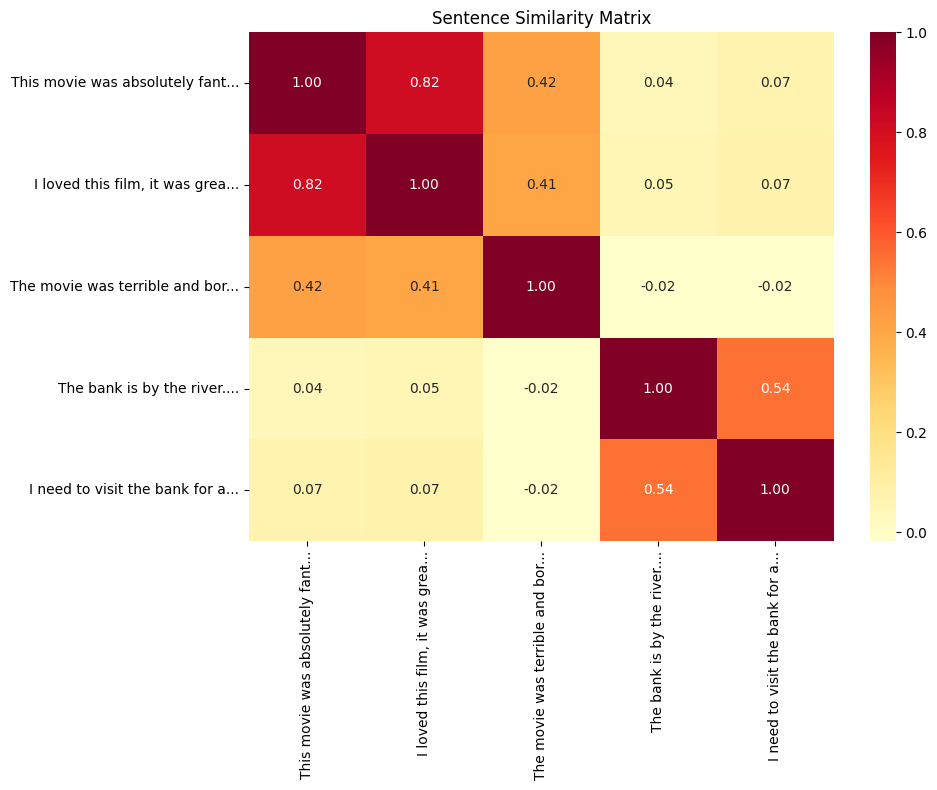

In [15]:
# Create a similarity matrix
similarity_matrix = cosine_similarity(embeddings)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, 
            xticklabels=[s[:30]+"..." for s in sentences],
            yticklabels=[s[:30]+"..." for s in sentences],
            annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Sentence Similarity Matrix")
plt.tight_layout()
plt.savefig('similarity_matrix.png', dpi=150)
plt.show()

## Part 4: Semantic Search

In [16]:
def semantic_search(query, corpus_embeddings, corpus_texts, top_k=5):
    """Find most similar documents to a query."""
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    results = []
    for idx in top_indices:
        results.append({
            'score': similarities[idx],
            'text': corpus_texts[idx][:200] + "..."
        })
    return results

# Test semantic search
query = "movies with surprising plot twists"

print("🔎 SEMANTIC SEARCH RESULTS")
print("=" * 60)
print(f"Query: \"{query}\"\n")

results = semantic_search(query, corpus_embeddings, texts)

print("Top 5 Results:")
for i, r in enumerate(results, 1):
    print(f"\n{i}. [Score: {r['score']:.2f}]")
    print(f"   {r['text']}")

🔎 SEMANTIC SEARCH RESULTS
Query: "movies with surprising plot twists"

Top 5 Results:

1. [Score: 0.55]
   TV version of "Twister" springs a few leaks but manages to remain watchable. My sister bought this at a Wal-Mart a few years back when it was released, I saw it back then and thought it was okay. Late...

2. [Score: 0.55]
   Look carefully at the wonderful assortment of talent put together to make this movie: Connery, Fishburne, Capshaw, Harris, Underwood, Beatty, Thigpen, even cameos by Slezak, Lange, and Plimpton. They ...

3. [Score: 0.55]
   I can't believe the likes of Guillermo del Toro and Kim Bassinger got involved ins this piece of garbage! The script is so poorly written and the directing so weak (both by the same person) that its h...

4. [Score: 0.54]
   Weak plot, predictable violence, only semi interesting characters. Like the writer (also one of the stars?) was fictionalizing his own screw ups and added an incredulous fantasies of drugs and murder ...

5. [Score: 0.

In [17]:
# Try more queries
queries = [
    "heartwarming family movies",
    "scary horror films",
    "romantic comedy with happy ending"
]

for query in queries:
    print(f"\n{'='*60}")
    print(f"Query: \"{query}\"")
    print("-" * 60)
    results = semantic_search(query, corpus_embeddings, texts, top_k=3)
    for i, r in enumerate(results, 1):
        print(f"{i}. [{r['score']:.2f}] {r['text'][:100]}...")


Query: "heartwarming family movies"
------------------------------------------------------------
1. [0.49] I very much looked forward to this movie. Its a good family movie; however, if Michael Landon Jr.'s ...
2. [0.48] "Valentine" is another horror movie to add to the stalk and slash movie list (think "Halloween", "Fr...
3. [0.48] Jack Frost, no kids it's not the warm hearted family movie about a dad who comes back from the dead ...

Query: "scary horror films"
------------------------------------------------------------
1. [0.65] This is the single worst movie I have ever seen. Let me say that again: THIS IS THE SINGLE WORST MOV...
2. [0.64] normally i'm not the sort to be scared by horror movies, but this movie is the exception. some how t...
3. [0.62] A far as B-movies go, SCARECROW is one of those that are so bad, that it becomes incredibly annoying...

Query: "romantic comedy with happy ending"
------------------------------------------------------------
1. [0.55] A poorly writ

## Part 5: Analysis

In [18]:
# Compare semantic search vs keyword search
query = "films I didn't enjoy"

print("📊 SEMANTIC vs KEYWORD SEARCH")
print("=" * 60)
print(f"Query: \"{query}\"\n")

# Semantic search
print("SEMANTIC SEARCH (embedding-based):")
semantic_results = semantic_search(query, corpus_embeddings, texts, top_k=3)
for i, r in enumerate(semantic_results, 1):
    print(f"  {i}. [{r['score']:.2f}] {r['text'][:80]}...")

# Simple keyword search
print("\nKEYWORD SEARCH (exact match):")
keyword_results = [t[:80] for t in texts if 'enjoy' in t.lower()][:3]
if keyword_results:
    for i, r in enumerate(keyword_results, 1):
        print(f"  {i}. {r}...")
else:
    print("  No exact matches found!")

print("\n💡 Notice: Semantic search understands meaning, not just keywords!")

📊 SEMANTIC vs KEYWORD SEARCH
Query: "films I didn't enjoy"

SEMANTIC SEARCH (embedding-based):
  1. [0.58] There are bad movies, terrible movies even boring movies...I can watch most and ...
  2. [0.57] There are bad movies, then there are the movies that are SO bad, that they becom...
  3. [0.55] Personally, while I'm able to appreciate really good movies, I also have a stran...

KEYWORD SEARCH (exact match):
  1. Really, I can't believe that I spent $5 on this movie. I am a huge zombie fanati...
  2. I very much looked forward to this movie. Its a good family movie; however, if M...
  3. I have read all of the Love Come Softly books. Knowing full well that movies can...

💡 Notice: Semantic search understands meaning, not just keywords!
